In [1]:
# 한글 글꼴 설치
!apt-get -qq install fonts-noto-cjk
!rm -rf /root/.cache/matplotlib/* # 캐시 재설정

In [2]:
# 런타임 다시 시작 후 실행
%matplotlib inline
import matplotlib as mpl
# Noto Sans CJK 폰트를 기본으로 설정
mpl.rc('font', family='Noto Sans CJK JP')
mpl.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

In [3]:
# kaggle 에서 발급 받은 키를 KGAT_xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx 위치에 넣어주세요.
!mkdir -p ~/.kaggle && echo KGAT_xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [4]:
!kaggle competitions download -c titanic
!unzip -o titanic.zip

titanic.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  titanic.zip
  inflating: gender_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


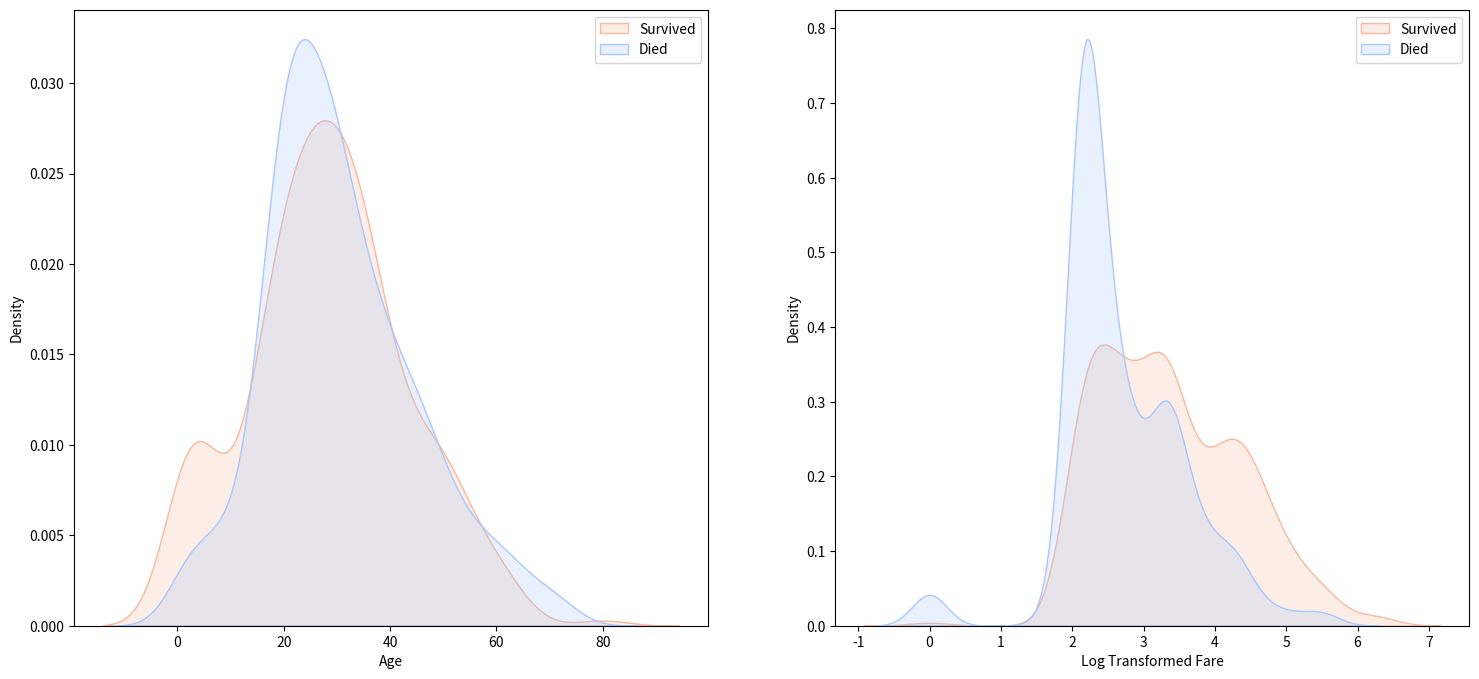

In [5]:
# T06_01.py
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 데이터 로드
train_df = pd.read_csv('train.csv') # ①
fig, axes = plt.subplots(1, 2, figsize=(18, 8)) # ②

# Age 분포에 따른 생존/사망자 시각화
sns.kdeplot(data=train_df, x='Age', hue='Survived', fill=True,
            common_norm=False, palette='coolwarm', ax=axes[0]) # ③
axes[0].legend(labels=['Survived','Died']) # ④

# Fare 분포에 따른 생존/사망자 시각화(로그 변환 적용)
sns.kdeplot(data=train_df, x=np.log1p(train_df['Fare']),
  hue='Survived', fill=True,
  common_norm=False, palette='coolwarm', ax=axes[1]) # ⑤
axes[1].set_xlabel('Log Transformed Fare') # ⑥
axes[1].legend(labels=['Survived','Died']) # ⑦

plt.show()

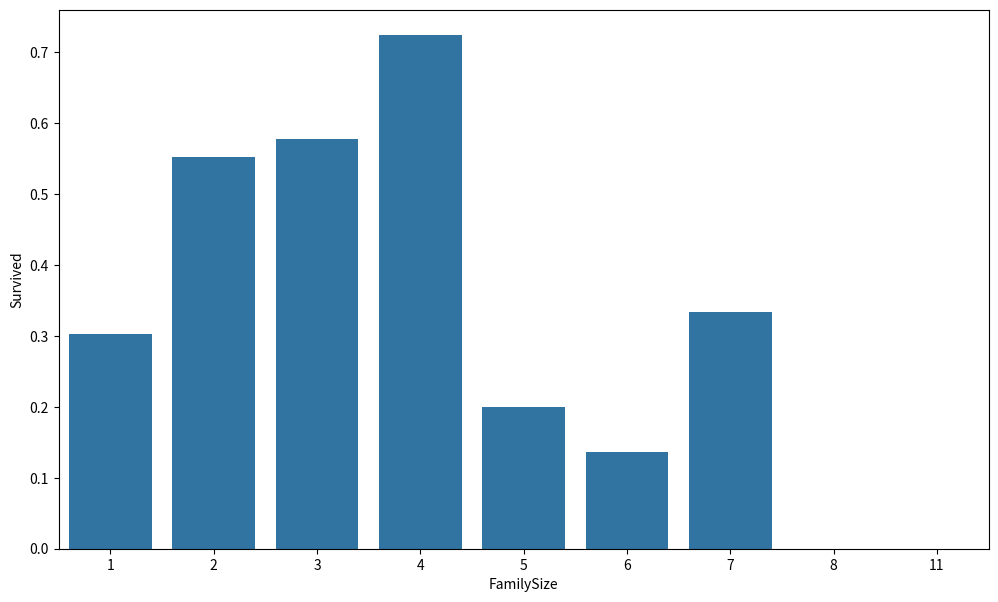

In [6]:
# T06_02.py
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1 # ①

plt.figure(figsize=(12, 7))
sns.barplot(x='FamilySize', y='Survived', data=train_df, errorbar=None) # ②
plt.show()

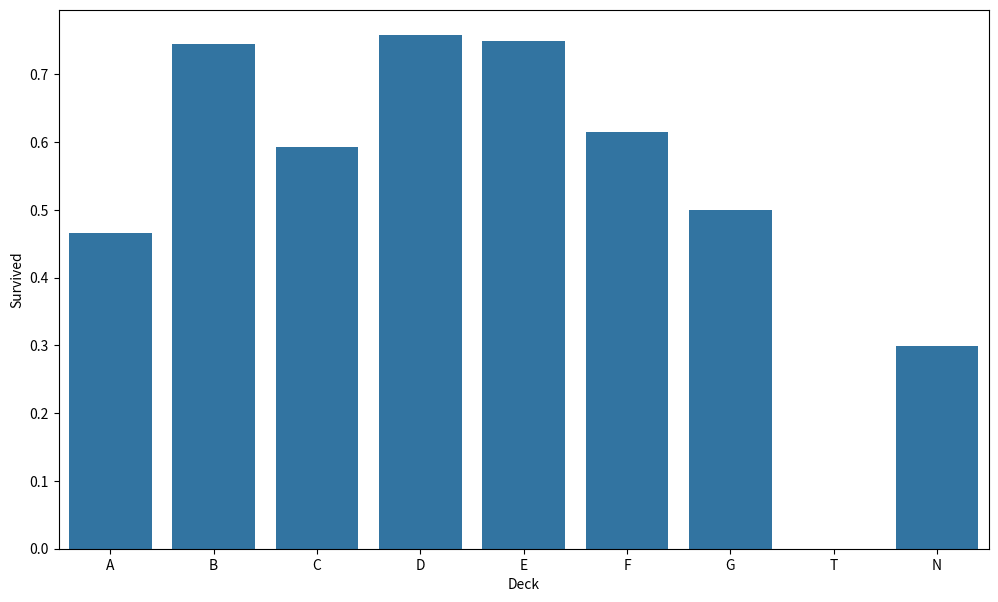

In [7]:
# T06_03.py
train_df['Deck'] = train_df['Cabin'].str[0].fillna('N') # ①

plt.figure(figsize=(12, 7))
sns.barplot(x='Deck', y='Survived', data=train_df,
            order=['A','B','C','D','E','F','G','T','N'], errorbar=None) # ②
plt.show()

In [8]:
# T06_04.py
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 데이터 로드
# Kaggle 경진대회 페이지에서 train.csv, test.csv를 다운로드 받아야 한다.
try:
  train_df = pd.read_csv('train.csv') # ①
  test_df = pd.read_csv('test.csv') # ②
except FileNotFoundError:
  print("Kaggle 'Titanic' 경진대회의 train.csv, test.csv 파일이 필요합니다.")
  # 실습 진행을 위해 빈 데이터프레임으로 대체
  train_df, test_df = pd.DataFrame(), pd.DataFrame()

# 베이스라인 전처리를 수행하는 함수
def baseline_preprocess(df):
  # 원본 데이터는 보존하기 위해 복사본 사용
  df_copy = df.copy() # ③

  # 불필요한 컬럼 제거
  df_copy = df_copy.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1) # ④

  # 결측치 처리
  # Age는 평균값, Fare는 중앙값, Embarked는 최빈값으로 채운다.
  df_copy['Age'] = df_copy['Age'].fillna(df_copy['Age'].mean()) # ⑤
  df_copy['Fare'] = df_copy['Fare'].fillna(df_copy['Fare'].median()) # ⑥
  df_copy['Embarked'] = df_copy['Embarked'].fillna(df_copy['Embarked'].mode()[0]) # ⑦

  # 범주형 피처를 수치형으로 변환(Label Encoding)
  categorical_features = ['Sex', 'Embarked'] # ⑧
  for feature in categorical_features: # ⑨
    le = LabelEncoder() # ⑩
    df_copy[feature] = le.fit_transform(df_copy[feature]) # ⑪

  return df_copy

if not train_df.empty:
  # 훈련 데이터와 테스트 데이터에 전처리 함수 적용
  train_processed = baseline_preprocess(train_df) # ⑫
  test_processed = baseline_preprocess(test_df) # ⑬

  # 피처와 타겟 데이터 분리
  X_train = train_processed.drop('Survived', axis=1) # ⑭
  y_train = train_processed['Survived'] # ⑮

  print("--- 전처리 후 훈련 데이터 (상위 5개) ---")
  print(X_train.head()) # ⑯

--- 전처리 후 훈련 데이터 (상위 5개) ---
   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0       3    1  22.0      1      0   7.2500         2
1       1    0  38.0      1      0  71.2833         0
2       3    0  26.0      0      0   7.9250         2
3       1    0  35.0      1      0  53.1000         2
4       3    1  35.0      0      0   8.0500         2


In [9]:
# T06_05.py
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

# 평가할 모델 목록
models = [
  LogisticRegression(random_state=42, max_iter=1000), # ①
  DecisionTreeClassifier(random_state=42), # ②
  RandomForestClassifier(random_state=42), # ③
  GradientBoostingClassifier(random_state=42), # ④
  XGBClassifier(random_state=42,
                eval_metric='logloss') # ⑤
]

if not train_df.empty:
  print("\n--- 모델별 5-Fold 교차 검증 평균 정확도 ---")
  for model in models:
    # 모델 객체로부터 모델 이름 가져오기
    model_name = model.__class__.__name__ # ⑥

    # 교차 검증 수행
    scores = cross_val_score(model,
                             X_train, y_train, cv=5,
                             scoring='accuracy') # ⑦

    # 결과 출력
    print(f"{model_name}: {np.mean(scores):.4f}") # ⑧


--- 모델별 5-Fold 교차 검증 평균 정확도 ---
LogisticRegression: 0.7868
DecisionTreeClassifier: 0.7655
RandomForestClassifier: 0.8115
GradientBoostingClassifier: 0.8205
XGBClassifier: 0.8160


In [10]:
# T06_06.py
# 훈련, 테스트 데이터 합쳐서 전처리 용이하게 하기
all_df = pd.concat([train_df, test_df], sort=False).reset_index(drop=True) # ①

# 정규표현식을 사용하여 Title 추출
all_df['Title'] = all_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False) # ②

# 분포 확인
print("\n--- 그룹화 전 Title 피처 분포 ---")
print(all_df['Title'].value_counts()) # ③

# 소수 희귀 Title을 'Rare' 등으로 그룹화
all_df['Title'] = all_df['Title'].replace(['Lady', 'Countess','Capt', 'Col',
                                           'Don', 'Dr', 'Major', 'Rev', 'Sir',
                                           'Jonkheer', 'Dona'], 'Rare') # ④
all_df['Title'] = all_df['Title'].replace('Mlle', 'Miss') # ⑤
all_df['Title'] = all_df['Title'].replace('Ms', 'Miss') # ⑥
all_df['Title'] = all_df['Title'].replace('Mme', 'Mrs') # ⑦

print("\n--- 그룹화 후 Title 피처 분포 ---")
print(all_df['Title'].value_counts()) # ⑧


--- 그룹화 전 Title 피처 분포 ---
Title
Mr          757
Miss        260
Mrs         197
Master       61
Rev           8
Dr            8
Col           4
Major         2
Mlle          2
Ms            2
Mme           1
Don           1
Sir           1
Lady          1
Capt          1
Countess      1
Jonkheer      1
Dona          1
Name: count, dtype: int64

--- 그룹화 후 Title 피처 분포 ---
Title
Mr        757
Miss      264
Mrs       198
Master     61
Rare       29
Name: count, dtype: int64


In [11]:
# T06_07.py
# Title 그룹별 평균 나이 계산
title_age_mean = all_df.groupby('Title')['Age'].mean() # ①

# Age의 결측치를 해당 승객의 Title에 맞는 평균 나이로 채우기
for title in title_age_mean.index: # ②
  all_df.loc[(all_df['Age'].isnull()) & (all_df['Title'] == title), 'Age'] \
                                                         = title_age_mean[title] # ③

--- Ticket 접두사별 빈도 ---
Ticket_Prefix
NUM        1014
PC           92
CA           68
SOTONOQ      24
SCPARIS      19
WC           15
STONO        14
FCC           9
SOC           8
C             8
SOPP          7
SCAH          5
PP            4
WEP           4
FC            3
PPP           2
SC            2
SWPP          2
SP            1
SCOW          1
FA            1
SOP           1
AS            1
CASOTON       1
STONOQ        1
A             1
LP            1
Name: count, dtype: int64


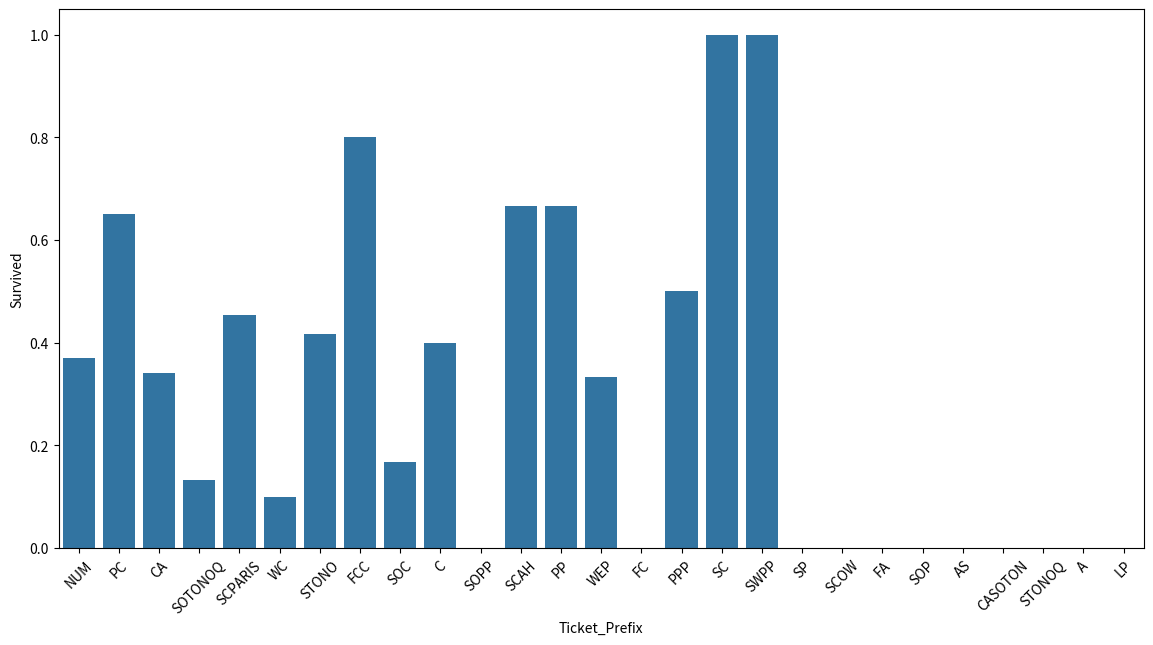

In [12]:
# T06_08.py
import matplotlib.pyplot as plt
import seaborn as sns
# Ticket 피처에서 문자열 부분만 추출하는 함수 정의

def extract_ticket_prefix(ticket): # ①
  parts = ticket.replace('.', '').replace('/', '').split() # ②
  if len(parts) > 1 and parts[0].isalpha(): # ③
    return parts[0].upper() # ④
  else:
    return 'NUM' # ⑤

# 새로운 'Ticket_Prefix' 피처 생성
all_df['Ticket_Prefix'] = all_df['Ticket'].apply(extract_ticket_prefix) # ⑥

print("--- Ticket 접두사별 빈도 ---")
print(all_df['Ticket_Prefix'].value_counts()) # ⑦

# 훈련 데이터셋만 사용하여 Ticket_Prefix별 생존율 계산 및 시각화
plt.figure(figsize=(14, 7))
sns.barplot(x='Ticket_Prefix',
            y='Survived', data=all_df[~all_df['Survived'].isnull()],
            order=all_df['Ticket_Prefix'].value_counts().index, errorbar=None) # ⑧
plt.xticks(rotation=45) # ⑨
plt.show()


--- Cabin 현측(Side) 피처 분포 ---
Cabin_Side
Unknown      1020
Starboard     154
Port          135
Name: count, dtype: int64


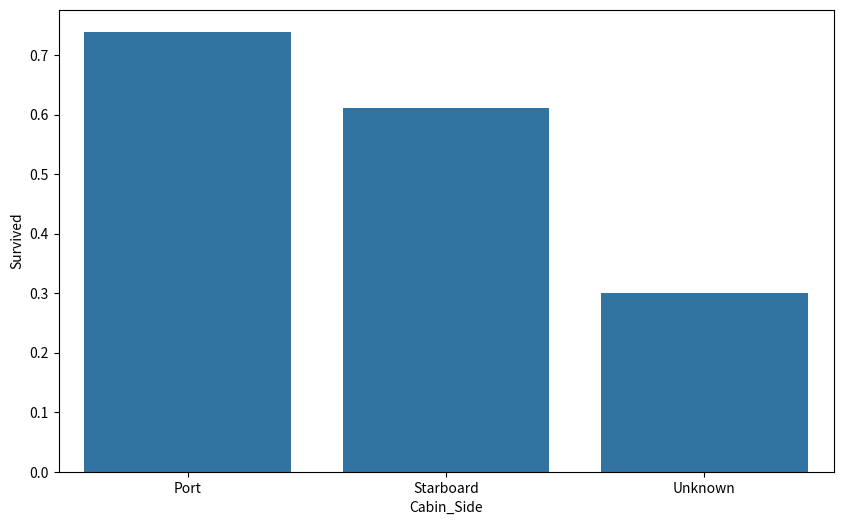

In [13]:
# T06_09.py
# Cabin 번호에서 숫자 부분만 추출
all_df['Cabin_Num'] = all_df['Cabin'].str.extract(r'(\d+)') # ①
all_df['Cabin_Num'] = pd.to_numeric(all_df['Cabin_Num'], errors='coerce') # ②

# 결측치가 아닌 경우에만 홀/짝 여부 판단
all_df.loc[all_df['Cabin_Num'].notna(), 'Cabin_Side'] = np.where(all_df.loc[all_df['Cabin_Num'].notna(), 'Cabin_Num'] % 2 == 0, 'Starboard', 'Port') # ③
all_df['Cabin_Side'] = all_df['Cabin_Side'].fillna('Unknown') # ④

print(f"\n--- Cabin 현측(Side) 피처 분포 ---")
print(all_df['Cabin_Side'].value_counts()) # ⑤

# Cabin 현측에 따른 생존율 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='Cabin_Side', y='Survived', data=all_df[~all_df['Survived'].isnull()],
 order=['Port', 'Starboard', 'Unknown'], errorbar=None) # ⑥
plt.show()

In [14]:
# T06_10.py
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# FamilySize 피처 생성, 결측치 보완
all_df['FamilySize'] = all_df['SibSp'] + all_df['Parch'] + 1
all_df['Embarked'] = all_df['Embarked'].fillna(all_df['Embarked'].mode()[0])
all_df['Fare'] = all_df['Fare'].fillna(all_df['Fare'].median())

# 불필요한 컬럼 제거
all_df_featured = all_df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch'], axis=1)

# 전처리 파이프라인 정의
numeric_features = ['Age', 'Fare', 'FamilySize']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title']

numeric_transformer = Pipeline(steps=[
  ('imputer', SimpleImputer(strategy='median')),
  ('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[
  ('imputer', SimpleImputer(strategy='most_frequent')),
  ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(
  transformers=[
  ('num', numeric_transformer, numeric_features),
  ('cat', categorical_transformer, categorical_features)])

In [15]:
# T06_11.py
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

# 전처리기와 모델을 최종 파이프라인으로 연결
pipeline_gb = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier',
                               GradientBoostingClassifier(random_state=42))]) # ①

# 초매개변수 탐색 공간 정의
param_grid = {
  'classifier__n_estimators': [100, 200],
  'classifier__learning_rate': [0.05, 0.1],
  'classifier__max_depth': [3, 5]
} # ②

# 훈련 데이터 분리(전처리 전 원본 데이터 사용)
train_featured_df = all_df_featured[~all_df_featured['Survived'].isnull()] # ③
X_train = train_featured_df.drop('Survived', axis=1) # ④
y_train = train_featured_df['Survived'] # ⑤

# GridSearchCV 수행
grid_search = GridSearchCV(pipeline_gb,
                           param_grid, cv=5,
                           scoring='accuracy',
                           n_jobs=-1) # ⑥
grid_search.fit(X_train, y_train) # ⑦

print("--- GridSearchCV 결과 ---")
print(f"최적 초매개변수: {grid_search.best_params_}") # ⑧
print(f"최고 교차 검증 정확도: {grid_search.best_score_:.4f}") # ⑨

--- GridSearchCV 결과 ---
최적 초매개변수: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 200}
최고 교차 검증 정확도: 0.8417


In [16]:
# T06_12.py
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 튜닝된 매개변수로 개별 모델 정의
lr_clf = LogisticRegression(random_state=42, max_iter=1500) # ①
rf_clf = RandomForestClassifier(random_state=42, n_estimators=320) # ②

# GradientBoostingClassifier의 최적의 초매개변수 추출
gb_best_params = {} # ③
for key, value in grid_search.best_params_.items():
  clean_key = key.replace('classifier__', '') # ④
  gb_best_params[clean_key] = value

gb_clf = GradientBoostingClassifier(**gb_best_params, random_state=42) # ⑤

# 개별 모델들을 VotingClassifier에 통합
voting_clf = VotingClassifier(
  estimators=[('LR', lr_clf), ('RF', rf_clf), ('GB', gb_clf)], voting='soft') # ⑥

# 전처리기와 보팅 모델을 파이프라인으로 연결
pipeline_voting = Pipeline(steps=[('preprocessor', preprocessor),
                                  ('classifier', voting_clf)]) # ⑦

# 교차 검증으로 최종 앙상블 모델 성능 평가
voting_scores = cross_val_score(pipeline_voting,
                                X_train, y_train, cv=5,
                                scoring='accuracy') # ⑧

print("\n--- 보팅 앙상블 모델 성능 ---")
print(f"5-Fold 교차 검증 평균 정확도: {np.mean(voting_scores):.4f}") # ⑨


--- 보팅 앙상블 모델 성능 ---
5-Fold 교차 검증 평균 정확도: 0.8429


In [17]:
# T06_13.py
# 최종 모델(파이프라인)을 전체 훈련 데이터로 학습
pipeline_voting.fit(X_train, y_train) # ①

# 전처리 전 원본 테스트 데이터 로드
test_original_df = pd.read_csv('test.csv') # ②

# 예측에 필요한 피처만 남김(전처리 함수 재활용 또는 직접 처리)
X_test_final = all_df_featured[all_df_featured['Survived'].isnull()].drop('Survived',axis=1) # ③

# 테스트 데이터에 대한 예측 수행
predictions = pipeline_voting.predict(X_test_final).astype(int) # ④

# 캐글 제출 형식에 맞는 submission.csv 파일 생성
submission_df = pd.DataFrame({
 "PassengerId": test_original_df["PassengerId"],
 "Survived": predictions
}) # ⑤

submission_df.to_csv('submission.csv', index=False) # ⑥

print("\n'submission.csv' 파일이 생성되었습니다. 캐글에 제출하여 리더보드 점수를 확인해보세요!")


'submission.csv' 파일이 생성되었습니다. 캐글에 제출하여 리더보드 점수를 확인해보세요!


In [18]:
# Join Competition
# https://www.kaggle.com/c/spaceship-titanic
!kaggle competitions download -c spaceship-titanic
!unzip -o spaceship-titanic.zip

spaceship-titanic.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  spaceship-titanic.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


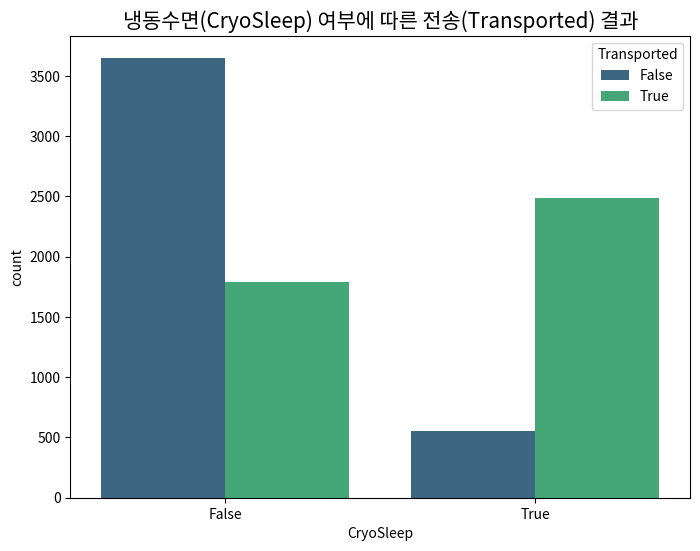

/tmp/ipykernel_6997/3943677751.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_df, x='HomePlanet', y='Transported', errorbar=None, palette='plasma') # ④


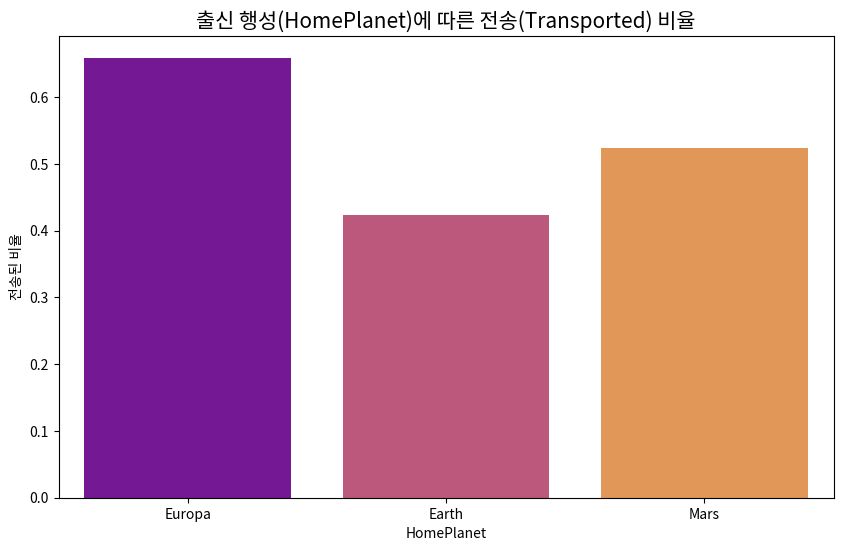

In [19]:
# Q06_01.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 로드
try:
  train_df = pd.read_csv('train.csv') # ①
  test_df = pd.read_csv('test.csv') # ②
except FileNotFoundError:
  print("Kaggle 'Spaceship Titanic' 경진대회의 train.csv 파일이 필요합니다.")
  train_df = pd.DataFrame()

# CryoSleep 피처 분석 (CryoSleep(냉동수면) 상태인 승객은 활동이 없으므로, 사고 발생 시 상황이 다를 수 있음)
plt.figure(figsize=(8, 6))
sns.countplot(data=train_df, x='CryoSleep', hue='Transported', palette='viridis') # ③
plt.title('냉동수면(CryoSleep) 여부에 따른 전송(Transported) 결과', size=15)
plt.show()

# HomePlanet 피처 분석(출신 행성에 따라 사회적 지위나 구명정 접근성이 달랐을 수 있음)
plt.figure(figsize=(10, 6))
sns.barplot(data=train_df, x='HomePlanet', y='Transported', errorbar=None, palette='plasma') # ④
plt.title('출신 행성(HomePlanet)에 따른 전송(Transported) 비율', size=15)
plt.ylabel('전송된 비율')
plt.show()

/tmp/ipykernel_6997/575429361.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=train_df, x='Deck', y='Transported',


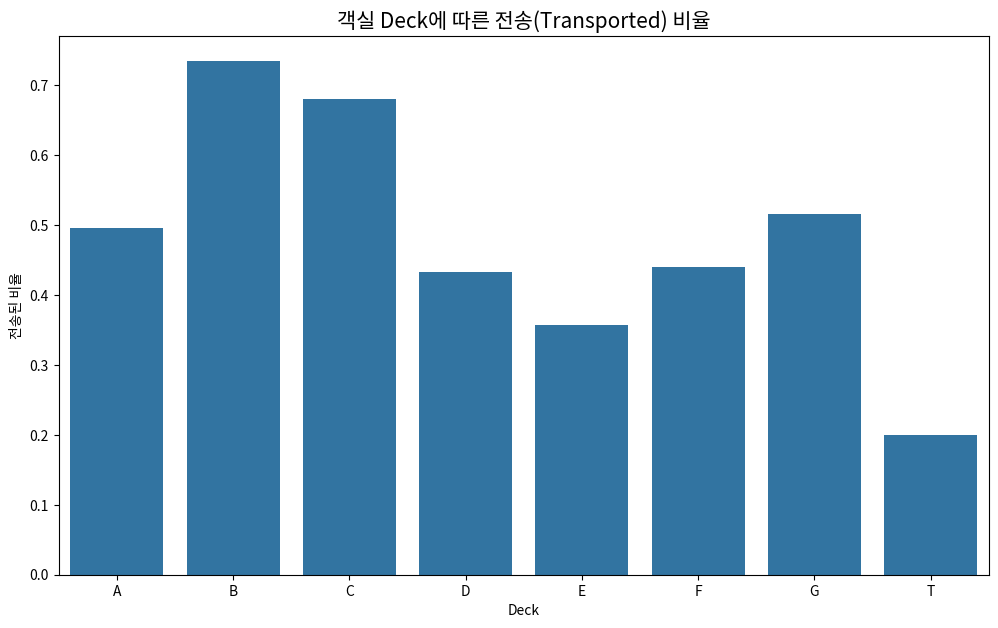

In [20]:
# Q06_02.py
# Cabin 피처를 '/' 기준으로 분리하여 새로운 컬럼 생성
train_df[['Deck', 'Cabin_num', 'Side']] = train_df['Cabin'].str.split('/', expand=True) # ①

# 새로 생성된 Deck 피처와 Transported의 관계 시각화
plt.figure(figsize=(12, 7))
sns.barplot(data=train_df, x='Deck', y='Transported',
            order=sorted(train_df['Deck'].dropna().unique()), ci=None) # ②
plt.title('객실 Deck에 따른 전송(Transported) 비율', size=15)
plt.ylabel('전송된 비율')
plt.show()